In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
# ---------------------------------------------------
# LOAD DATASET
# ---------------------------------------------------

# Load Iris dataset
data = pd.read_csv(r"C:\Users\2539990\Documents\Iris Neural Network Classification Project\Iris_DataSet.csv", sep=";", header=None)
data.columns = [
    "SepalLength",
    "SepalWidth",
    "PetalLength",
    "PetalWidth",
    "Species"
]

# Display first rows
print(data.head())

   SepalLength  SepalWidth  PetalLength  PetalWidth      Species
0          5.1         3.5          1.4         0.2  Iris-setosa
1          4.9         3.0          1.4         0.2  Iris-setosa
2          4.7         3.2          1.3         0.2  Iris-setosa
3          4.6         3.1          1.5         0.2  Iris-setosa
4          5.0         3.6          1.4         0.2  Iris-setosa


In [3]:
# ---------------------------------------------------
# PREPARE INPUTS AND TARGETS
# ---------------------------------------------------
# Features
X = data.iloc[:, :-1]

# Labels
y = data.iloc[:, -1]

In [4]:
# ---------------------------------------------------
# NORMALISE INPUT VALUES
# USING MAX-MIN NORMALISATION
# ---------------------------------------------------

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)
print(X_scaled[:5])

# ---------------------------------------------------
# ONE-HOT ENCODING OF TARGET VALUES
# ---------------------------------------------------

encoder = OneHotEncoder(sparse_output=False)

y_encoded = encoder.fit_transform(y.values.reshape(-1, 1))

[[0.22222222 0.625      0.06779661 0.04166667]
 [0.16666667 0.41666667 0.06779661 0.04166667]
 [0.11111111 0.5        0.05084746 0.04166667]
 [0.08333333 0.45833333 0.08474576 0.04166667]
 [0.19444444 0.66666667 0.06779661 0.04166667]]


In [5]:
# ---------------------------------------------------
# ONE-HOT ENCODING OF TARGET VALUES
# ---------------------------------------------------

encoder = OneHotEncoder(sparse_output=False)

y_encoded = encoder.fit_transform(y.values.reshape(-1, 1))

In [6]:
# ---------------------------------------------------
# SPLIT DATASET
# 50% TRAINING
# 25% VALIDATION
# 25% TESTING
# ---------------------------------------------------

X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.5,
    random_state=42
)

X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42
)

In [7]:
# ---------------------------------------------------
# CREATE NEURAL NETWORK
# ---------------------------------------------------

model = MLPClassifier(
    hidden_layer_sizes=(20,),
    activation='relu',
    solver='sgd',
    max_iter=1,
    warm_start=True,
    random_state=42
)

In [8]:

# # ---------------------------------------------------
# # TRAIN NETWORK EPOCH BY EPOCH
# # ---------------------------------------------------
train_losses = []
validation_losses = []

epochs = 100

for epoch in range(epochs):

    model.fit(X_train, y_train)

    train_predictions = model.predict_proba(X_train)
    validation_predictions = model.predict_proba(X_validation)

    train_loss = np.sum((y_train - train_predictions) ** 2)
    validation_loss = np.sum((y_validation - validation_predictions) ** 2)

    train_losses.append(train_loss)
    validation_losses.append(validation_loss)

    print(f"Epoch {epoch+1}")
    print("Training Loss:", train_loss)
    print("Validation Loss:", validation_loss)

Epoch 1
Training Loss: 61.504954731254756
Validation Loss: 30.747271875536892
Epoch 2
Training Loss: 61.46845519809817
Validation Loss: 30.729527593950188
Epoch 3
Training Loss: 61.43207149638592
Validation Loss: 30.711838847011844
Epoch 4
Training Loss: 61.39580311475322
Validation Loss: 30.69420539220876
Epoch 5
Training Loss: 61.359649544483545
Validation Loss: 30.676626988270424
Epoch 6
Training Loss: 61.32361027949531
Validation Loss: 30.65910339516273
Epoch 7
Training Loss: 61.28768481632855
Validation Loss: 30.64163437408194
Epoch 8
Training Loss: 61.25187265413156
Validation Loss: 30.6242237430765
Epoch 9
Training Loss: 61.21617623966001
Validation Loss: 30.606851981084287
Epoch 10
Training Loss: 61.1806004060996
Validation Loss: 30.58953793512027
Epoch 11
Training Loss: 61.14514250215497
Validation Loss: 30.572277627592825
Epoch 12
Training Loss: 61.10981689058766
Validation Loss: 30.55507447855303
Epoch 13
Training Loss: 61.0746019460322
Validation Loss: 30.537928730898624
Ep

c:\Users\2539990\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\2539990\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\2539990\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\2539990\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the opti

In [9]:
# ---------------------------------------------------
# TESTING PHASE
# ---------------------------------------------------

# Predict test data
test_predictions = model.predict(X_test)

# Convert one-hot encoded values to class labels
y_test_labels = np.argmax(y_test, axis=1)

test_prediction_labels = np.argmax(test_predictions, axis=1)

# Calculate accuracy
accuracy = accuracy_score(
    y_test_labels,
    test_prediction_labels
)

# Display accuracy
print("\nFinal Test Accuracy:", accuracy)



Final Test Accuracy: 0.2894736842105263


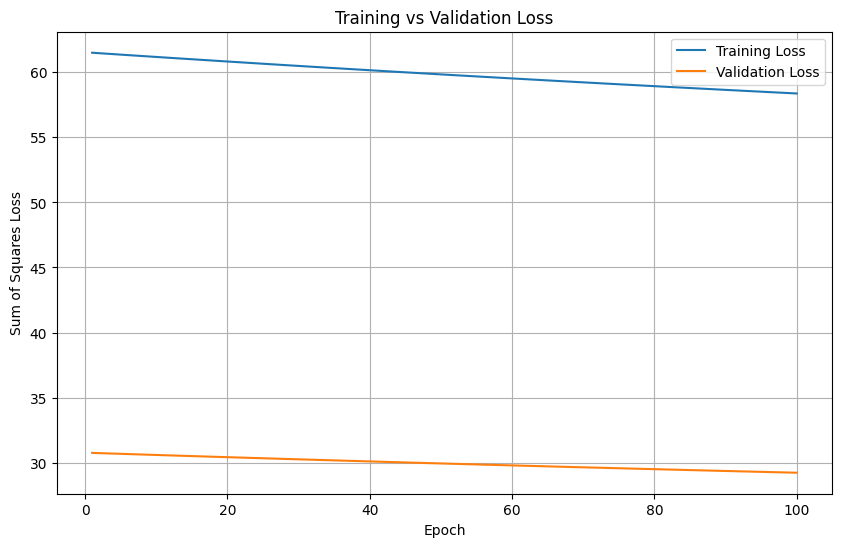

In [10]:
plt.figure(figsize=(10,6))

plt.plot(range(1, epochs + 1), train_losses,
         label='Training Loss')

plt.plot(range(1, epochs + 1), validation_losses,
         label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Sum of Squares Loss')
plt.title('Training vs Validation Loss')

plt.legend()

plt.grid(True)

plt.show()

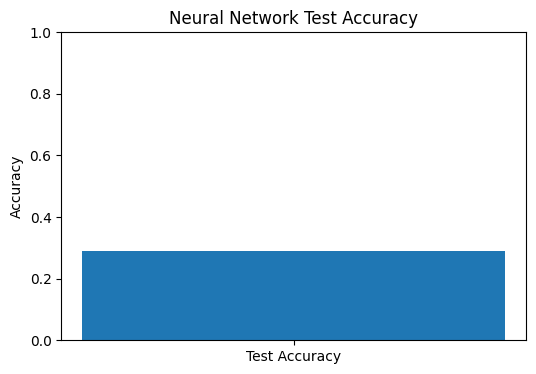

In [11]:
plt.figure(figsize=(6,4))

plt.bar(['Test Accuracy'], [accuracy])

plt.ylabel('Accuracy')
plt.title('Neural Network Test Accuracy')

plt.ylim(0, 1)

plt.show()

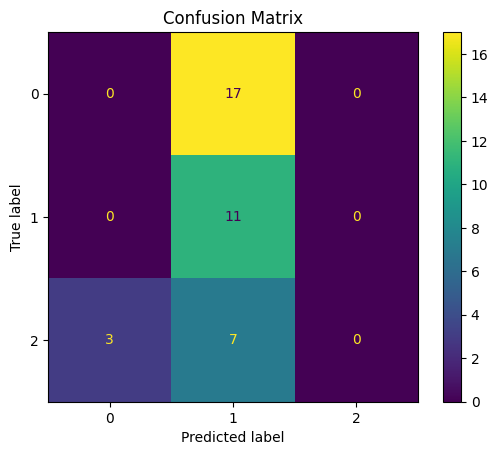

In [12]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test_labels,
    test_prediction_labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Confusion Matrix")

plt.show()